# Prática — Módulo 11: Estudo de Caso

In [42]:
# Importações
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from sklearn.model_selection import train_test_split


# **Setup dos Dados**

In [43]:
df = pd.read_csv("mlp_score_1024.csv")

df = df.drop(columns=["index"])

df.head()

,renda,score_credito,endividamento,historico_pagamento,tempo_relacionamento,aprovado
0,0.374540,0.950714,0.731994,0.598658,0.156019,0
1,0.155995,0.058084,0.866176,0.601115,0.708073,0
2,0.020584,0.969910,0.832443,0.212339,0.181825,0
3,0.183405,0.304242,0.524756,0.431945,0.291229,0
4,0.611853,0.139494,0.292145,0.366362,0.456070,0


## Perguntas
1. A função gerou dados que são linearmente separáveis?
2. Há regiões onde as classes parecem se misturar?
3. O problema parece simples ou complexo visualmente?


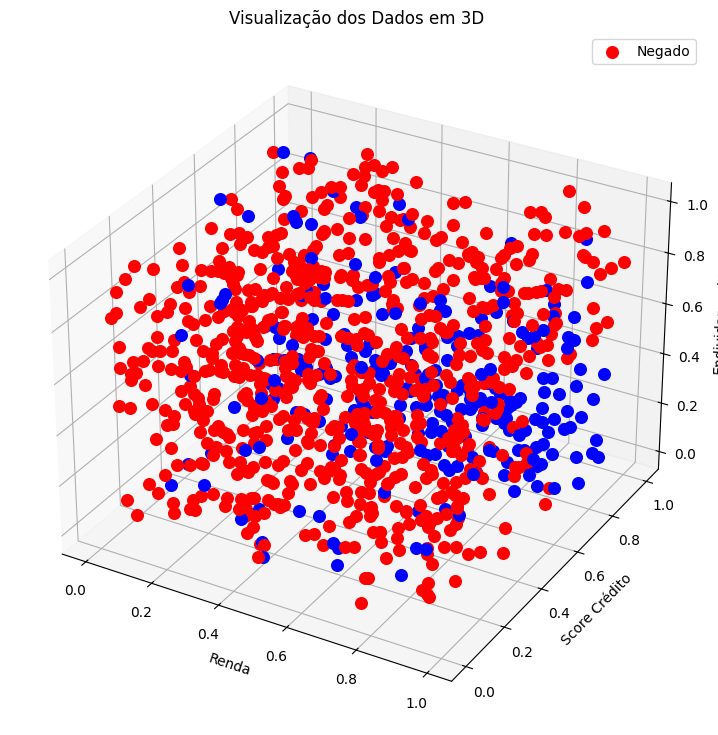

In [44]:
fig = plt.figure(figsize=(9,9))

ax = fig.add_subplot(111, projection='3d')

for i in range(len(df)):

    if df["aprovado"][i] == 0:
        ax.scatter(
            df["renda"][i],
            df["score_credito"][i],
            df["endividamento"][i],
            color='red',
            s=70,
            label='Negado' if i == 0 else ""
        )

    else:
        ax.scatter(
            df["renda"][i],
            df["score_credito"][i],
            df["endividamento"][i],
            color='blue',
            s=70,
            label='Aprovado' if i == 3 else ""
        )

ax.set_xlabel("Renda")
ax.set_ylabel("Score Crédito")
ax.set_zlabel("Endividamento")

ax.set_title("Visualização dos Dados em 3D")

ax.legend()

plt.show()

## Perguntas
1. Qual variável representa a saída esperada?
2. O problema é de regressão ou classificação?

In [45]:
# Separar variáveis de entrada da variável alvo

X = df.drop(columns=["aprovado"])
y = df["aprovado"]

print(X.head())
print(y.head())

      renda  score_credito  endividamento  historico_pagamento  \
0  0.374540       0.950714       0.731994             0.598658   
1  0.155995       0.058084       0.866176             0.601115   
2  0.020584       0.969910       0.832443             0.212339   
3  0.183405       0.304242       0.524756             0.431945   
4  0.611853       0.139494       0.292145             0.366362   

   tempo_relacionamento  
0              0.156019  
1              0.708073  
2              0.181825  
3              0.291229  
4              0.456070  
0    0
1    0
2    0
3    0
4    0
Name: aprovado, dtype: int64


In [46]:
# Dividir dados de treino e dados de teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(716, 5)
(308, 5)


# **Rede Rasa**

# Perguntas
1. Quantas camadas ocultas essa rede possui?
2. Quantos neurônios existem na camada oculta?
3. Essa arquitetura pode ser considerada rasa ou profunda?
4. Que função de ativação foi usada?

In [47]:
from sklearn.neural_network import MLPClassifier

mlp_rasa = MLPClassifier(
    hidden_layer_sizes=(2),
    activation='relu',
    max_iter=5000,
    random_state=42
)

mlp_rasa.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=2, max_iter=5000, random_state=42)

# Perguntas
1. Mesmo com somente dois neurônios, a rede rasa consegue aprender padrões?
2. A acurácia foi satisfatória?
3. Aumentar neurônios melhora os resultados (4, 6, 8,... 16)?

In [48]:
from sklearn.metrics import accuracy_score

pred_rasa = mlp_rasa.predict(X_test)

acc_rasa = accuracy_score(y_test, pred_rasa)

print(f"Acurácia Rede Rasa: {acc_rasa:.2f}")

Acurácia Rede Rasa: 0.86


# **Rede Profunda**

In [49]:
mlp_profunda = MLPClassifier(
    hidden_layer_sizes=(16, 12, 4),
    activation='relu',
    max_iter=5000,
    random_state=42
)

mlp_profunda.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(16, 12, 4), max_iter=5000, random_state=42)

In [50]:
pred_profunda = mlp_profunda.predict(X_test)

acc_profunda = accuracy_score(y_test, pred_profunda)

print(f"Acurácia Rede Profunda: {acc_profunda:.2f}")

Acurácia Rede Profunda: 0.90


# Perguntas
1. A rede profunda apresentou melhoria em relação à rasa?
2. O aumento de camadas aumentou o custo computacional?
3. A rede profunda apresentou sinais de overfitting?
4. Mais camadas necessariamente significam melhor desempenho?
5. Qual arquitetura apresentou melhor equilíbrio entre simplicidade e desempenho?